In [ ]:

# Upload final_data.csv when the button appears
from google.colab import files
import pandas as pd
import io

print("Please upload final_data.csv ...")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("File loaded!")
print("Shape:", df.shape)
df.head(3)

Please upload final_data.csv ...


Saving final_data (1).csv to final_data (1).csv
File loaded!
Shape: (22628, 12)


,Rating,Age,sentiment_score,sentiment_encoded,popularity_score,review_length,department_encoded,class_encoded,division_encoded,age_group_encoded,high_feedback,Recommended IND
0,4,33,0.6333,1,0.000000,8,2,5,2,2,0,1
1,5,34,0.3396,1,0.032787,62,1,3,0,2,1,1
2,3,60,0.0737,0,0.000000,98,1,3,0,4,0,0


In [ ]:
# Install and import everything we need for ML
!pip install scikit-learn -q

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)
import pickle
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded!")

All libraries loaded!


In [ ]:
# Define our features (X) and target (y)
# X = inputs to the model   |   y = what we want to predict

features = [
    'Rating',
    'Age',
    'sentiment_score',
    'sentiment_encoded',
    'popularity_score',
    'review_length',
    'department_encoded',
    'class_encoded',
    'division_encoded',
    'age_group_encoded',
    'high_feedback'
]

X = df[features]
y = df['Recommended IND']   # 1 = viral, 0 = not viral

print("Features (X) shape:", X.shape)
print("Target (y) shape  :", y.shape)
print("\nTarget breakdown:")
print(y.value_counts())
print(f"\nViral products: {round(y.mean()*100, 1)}%")

Features (X) shape: (22628, 11)
Target (y) shape  : (22628,)

Target breakdown:
Recommended IND
1    18527
0     4101
Name: count, dtype: int64

Viral products: 81.9%


In [ ]:

# Split data into TRAIN (80%) and TEST (20%)
# Train = model learns from this
# Test  = we check how well it learned

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,         # 20% for testing
    random_state=42,       # so results are same every run
    stratify=y             # keep same viral % in both splits
)

print("Data split done!")
print(f"Training rows : {len(X_train)}")
print(f"Testing rows  : {len(X_test)}")

Data split done!
Training rows : 18102
Testing rows  : 4526


In [ ]:

# Split data into TRAIN (80%) and TEST (20%)
# Train = model learns from this
# Test  = we check how well it learned

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,         # 20% for testing
    random_state=42,       # so results are same every run
    stratify=y             # keep same viral % in both splits
)

print("Data split done!")
print(f"Training rows : {len(X_train)}")
print(f"Testing rows  : {len(X_test)}")

Data split done!
Training rows : 18102
Testing rows  : 4526


In [ ]:

# TRAIN MODEL 1 — Logistic Regression (simple baseline)
# Think of this as drawing a straight line to separate viral vs not

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)
lr_acc   = accuracy_score(y_test, lr_preds)

print("=" * 40)
print("  LOGISTIC REGRESSION RESULTS")
print("=" * 40)
print(f"Accuracy : {round(lr_acc * 100, 2)}%")
print("\nDetailed Report:")
print(classification_report(y_test, lr_preds,
      target_names=['Not Viral', 'Viral']))

  LOGISTIC REGRESSION RESULTS
Accuracy : 93.02%

Detailed Report:
              precision    recall  f1-score   support

   Not Viral       0.80      0.82      0.81       820
       Viral       0.96      0.95      0.96      3706

    accuracy                           0.93      4526
   macro avg       0.88      0.89      0.88      4526
weighted avg       0.93      0.93      0.93      4526



In [ ]:

# TRAIN MODEL 2 — Random Forest (our main  model)
# Think of this as 100 decision trees voting together

rf_model = RandomForestClassifier(
    n_estimators=100,    # 100 trees vote together
    random_state=42,
    n_jobs=-1            # use all CPU cores (faster)
)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_acc   = accuracy_score(y_test, rf_preds)

print("=" * 40)
print("  RANDOM FOREST RESULTS")
print("=" * 40)
print(f"Accuracy : {round(rf_acc * 100, 2)}%")
print("\nDetailed Report:")
print(classification_report(y_test, rf_preds,
      target_names=['Not Viral', 'Viral']))

  RANDOM FOREST RESULTS
Accuracy : 93.11%

Detailed Report:
              precision    recall  f1-score   support

   Not Viral       0.80      0.83      0.81       820
       Viral       0.96      0.95      0.96      3706

    accuracy                           0.93      4526
   macro avg       0.88      0.89      0.89      4526
weighted avg       0.93      0.93      0.93      4526



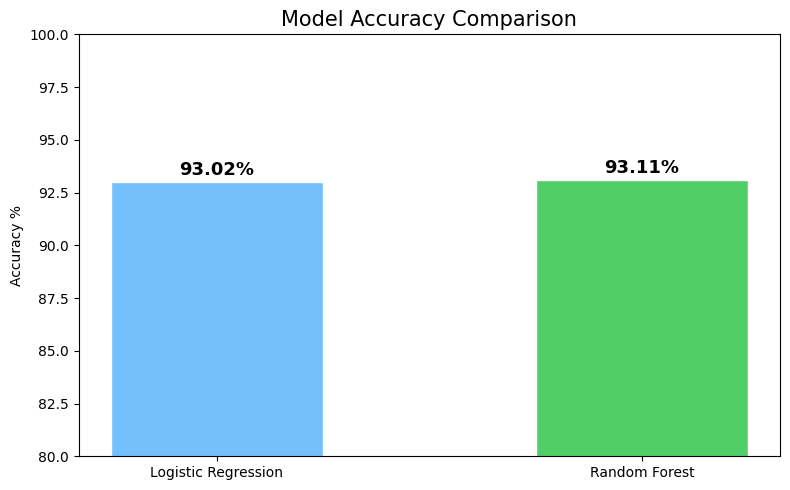


Winner: Random Forest


In [ ]:

# Compare both models side by side in a bar chart

models     = ['Logistic Regression', 'Random Forest']
accuracies = [round(lr_acc*100, 2), round(rf_acc*100, 2)]
colors     = ['#74c0fc', '#51cf66']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=colors, edgecolor='white', width=0.5)

# Add accuracy % on top of each bar
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f"{acc}%",
             ha='center', fontweight='bold', fontsize=13)

plt.title('Model Accuracy Comparison', fontsize=15)
plt.ylabel('Accuracy %')
plt.ylim(80, 100)
plt.tight_layout()
plt.show()

print(f"\nWinner: {'Random Forest' if rf_acc > lr_acc else 'Logistic Regression'}")

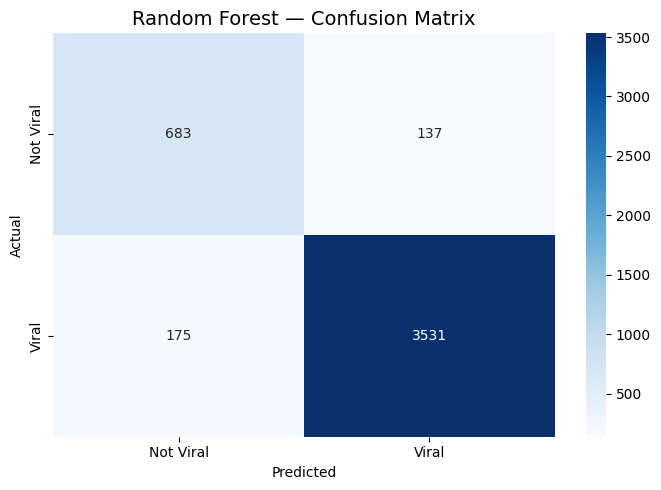


How to read this:
  Correctly predicted NOT viral : 683
  Correctly predicted VIRAL     : 3531
  Wrongly predicted viral       : 137
  Wrongly predicted not viral   : 175


In [ ]:

# Confusion Matrix for Random Forest
# Shows: how many predictions were right/wrong and in what category

cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Not Viral', 'Viral'],
            yticklabels=['Not Viral', 'Viral'])

plt.title('Random Forest — Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\nHow to read this:")
print(f"  Correctly predicted NOT viral : {cm[0][0]}")
print(f"  Correctly predicted VIRAL     : {cm[1][1]}")
print(f"  Wrongly predicted viral       : {cm[0][1]}")
print(f"  Wrongly predicted not viral   : {cm[1][0]}")

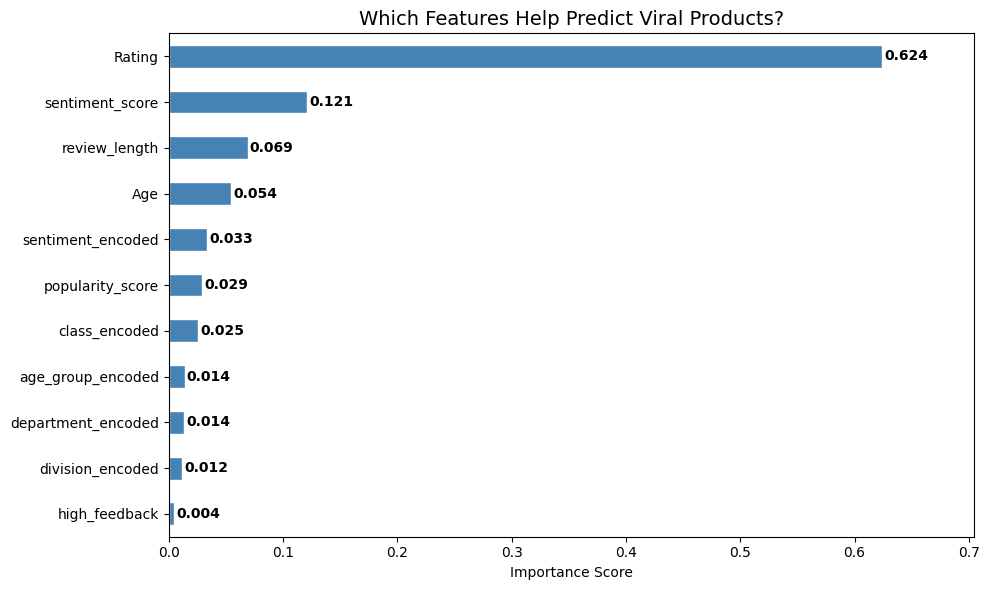


Top 3 most important features:
  Rating → 0.624
  sentiment_score → 0.121
  review_length → 0.069


In [ ]:
# Feature Importance — which input matters most for prediction?

importances = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue', edgecolor='white')

# Add scores on each bar
for i, v in enumerate(importances.values):
    plt.text(v + 0.002, i, str(round(v, 3)),
             va='center', fontweight='bold')

plt.title('Which Features Help Predict Viral Products?', fontsize=14)
plt.xlabel('Importance Score')
plt.xlim(0, importances.max() + 0.08)
plt.tight_layout()
plt.show()

print("\nTop 3 most important features:")
for feat, score in importances.sort_values(ascending=False).head(3).items():
    print(f"  {feat} → {round(score, 3)}")

In [ ]:

# Save the trained Random Forest model as a file
# We need this file for the Streamlit app later!

with open('model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# Also save the feature names so the app knows what order to send inputs
with open('features.pkl', 'wb') as f:
    pickle.dump(features, f)

print("Model saved as model.pkl")
print("Features saved as features.pkl")
print("\nThese 2 files are needed for the Streamlit app!")

Model saved as model.pkl
Features saved as features.pkl

These 2 files are needed for the Streamlit app!


In [ ]:
# Print final summary of everything

print("=" * 45)
print("   TRENDLENS — ML MODEL INSIGHTS")
print("=" * 45)
print(f"Logistic Regression Accuracy : {round(lr_acc*100, 2)}%")
print(f"Random Forest Accuracy       : {round(rf_acc*100, 2)}%")
print(f"Best Model                   : Random Forest")
top_feat = importances.sort_values(ascending=False).index[0]
print(f"Most Important Feature       : {top_feat}")
print(f"Training rows used           : {len(X_train)}")
print(f"Testing rows used            : {len(X_test)}")
print("=" * 45)

   TRENDLENS — ML MODEL INSIGHTS
Logistic Regression Accuracy : 93.02%
Random Forest Accuracy       : 93.11%
Best Model                   : Random Forest
Most Important Feature       : Rating
Training rows used           : 18102
Testing rows used            : 4526


In [ ]:
# Download both saved files to your desktop
from google.colab import files
files.download('model.pkl')
files.download('features.pkl')
print("Downloading model.pkl and features.pkl ...")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>